In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("sales_data.csv")

df.head()

,Invoice_ID,Date,Customer_Type,Gender,Product_Category,Unit_Price,Quantity,Payment_Method,City,Total_Sales,Rating
0,INV001,2026-01-05,Member,Female,Electronics,45000,1,UPI,Dahod,45000,5
1,INV002,2026-01-06,Normal,Male,Clothing,1200,3,Cash,Ahmedabad,3600,4
2,INV003,2026-01-08,Member,Male,Groceries,850,5,UPI,Vadodara,4250,4
3,INV004,2026-01-10,Normal,Female,Beauty,750,2,Card,Dahod,1500,5
4,INV005,2026-01-12,Member,Female,Electronics,32000,1,UPI,Ahmedabad,32000,4


In [3]:
df.shape

(30, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Invoice_ID        30 non-null     str  
 1   Date              30 non-null     str  
 2   Customer_Type     30 non-null     str  
 3   Gender            30 non-null     str  
 4   Product_Category  30 non-null     str  
 5   Unit_Price        30 non-null     int64
 6   Quantity          30 non-null     int64
 7   Payment_Method    30 non-null     str  
 8   City              30 non-null     str  
 9   Total_Sales       30 non-null     int64
 10  Rating            30 non-null     int64
dtypes: int64(4), str(7)
memory usage: 4.1 KB


In [5]:
df.columns

Index(['Invoice_ID', 'Date', 'Customer_Type', 'Gender', 'Product_Category',
       'Unit_Price', 'Quantity', 'Payment_Method', 'City', 'Total_Sales',
       'Rating'],
      dtype='str')

In [6]:
df.describe()

,Unit_Price,Quantity,Total_Sales,Rating
count,30.000000,30.000000,30.000000,30.000000
mean,11335.000000,3.333333,13661.666667,4.166667
std,17754.786387,2.170862,16456.141728,0.698932
min,500.000000,1.000000,1500.000000,3.000000
25%,812.500000,1.250000,3600.000000,4.000000
50%,1375.000000,3.000000,4500.000000,4.000000
75%,21625.000000,5.000000,23200.000000,5.000000
max,55000.000000,8.000000,55000.000000,5.000000


In [7]:
df.isnull().sum()

Invoice_ID          0
Date                0
Customer_Type       0
Gender              0
Product_Category    0
Unit_Price          0
Quantity            0
Payment_Method      0
City                0
Total_Sales         0
Rating              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Invoice_ID        30 non-null     str           
 1   Date              30 non-null     datetime64[us]
 2   Customer_Type     30 non-null     str           
 3   Gender            30 non-null     str           
 4   Product_Category  30 non-null     str           
 5   Unit_Price        30 non-null     int64         
 6   Quantity          30 non-null     int64         
 7   Payment_Method    30 non-null     str           
 8   City              30 non-null     str           
 9   Total_Sales       30 non-null     int64         
 10  Rating            30 non-null     int64         
dtypes: datetime64[us](1), int64(4), str(6)
memory usage: 3.8 KB


In [10]:
df["Month"] = df["Date"].dt.month_name()

df.head()

,Invoice_ID,Date,Customer_Type,Gender,Product_Category,Unit_Price,Quantity,Payment_Method,City,Total_Sales,Rating,Month
0,INV001,2026-01-05,Member,Female,Electronics,45000,1,UPI,Dahod,45000,5,January
1,INV002,2026-01-06,Normal,Male,Clothing,1200,3,Cash,Ahmedabad,3600,4,January
2,INV003,2026-01-08,Member,Male,Groceries,850,5,UPI,Vadodara,4250,4,January
3,INV004,2026-01-10,Normal,Female,Beauty,750,2,Card,Dahod,1500,5,January
4,INV005,2026-01-12,Member,Female,Electronics,32000,1,UPI,Ahmedabad,32000,4,January


In [11]:
df["Month_Number"] = df["Date"].dt.month

In [12]:
total_sales = df["Total_Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 409850


In [13]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 100


In [14]:
average_sales = df["Total_Sales"].mean()

print("Average Sales per Transaction:", round(average_sales, 2))

Average Sales per Transaction: 13661.67


In [15]:
category_sales = df.groupby("Product_Category")["Total_Sales"].sum().sort_values(ascending=False)

print(category_sales)

Product_Category
Electronics    314000
Clothing        47600
Groceries       33300
Beauty          14950
Name: Total_Sales, dtype: int64


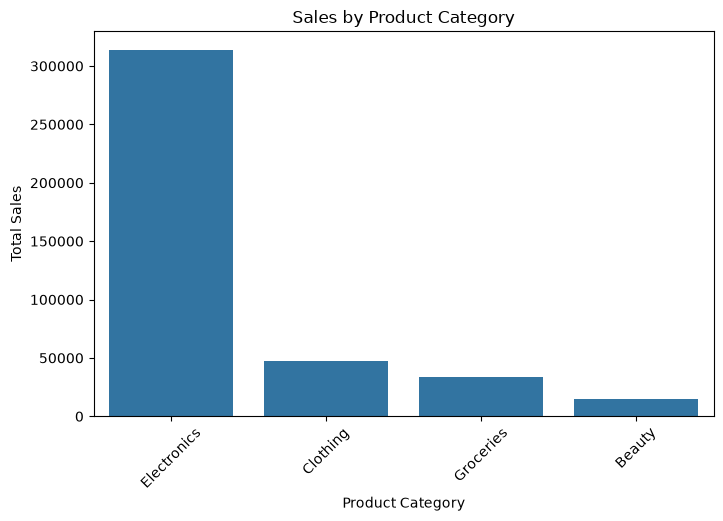

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [17]:
city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

print(city_sales)

City
Vadodara     147150
Ahmedabad    141600
Dahod        121100
Name: Total_Sales, dtype: int64


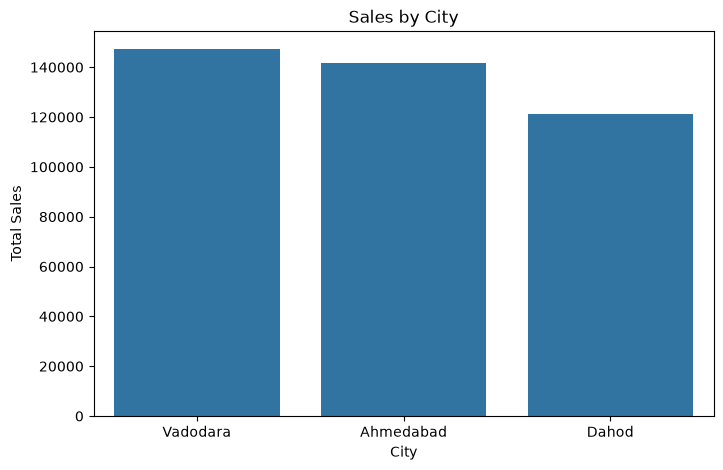

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=city_sales.index,
    y=city_sales.values
)

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.show()

In [19]:
gender_sales = df.groupby("Gender")["Total_Sales"].sum()

print(gender_sales)

Gender
Female    222350
Male      187500
Name: Total_Sales, dtype: int64


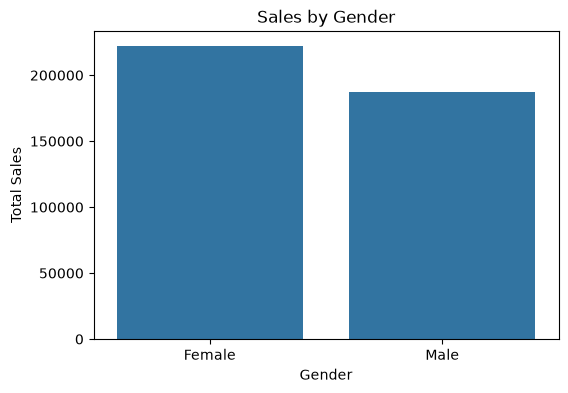

In [20]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values
)

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()

In [21]:
payment_counts = df["Payment_Method"].value_counts()

print(payment_counts)

Payment_Method
UPI     13
Card     9
Cash     8
Name: count, dtype: int64


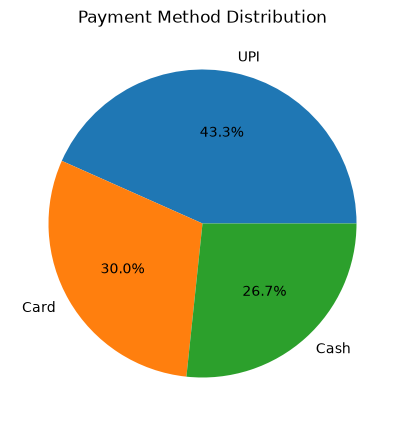

In [22]:
plt.figure(figsize=(7,5))

payment_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.show()

In [23]:
customer_sales = df.groupby("Customer_Type")["Total_Sales"].sum()

print(customer_sales)

Customer_Type
Member    239850
Normal    170000
Name: Total_Sales, dtype: int64


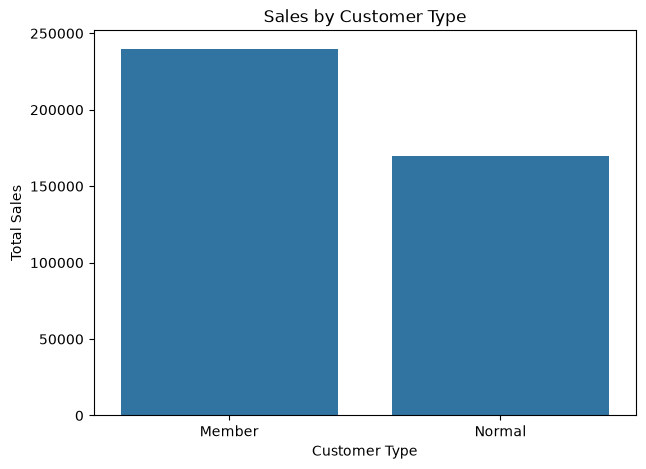

In [24]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=customer_sales.index,
    y=customer_sales.values
)

plt.title("Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")

plt.show()

In [25]:
monthly_sales = df.groupby("Month_Number")["Total_Sales"].sum()

print(monthly_sales)

Month_Number
1    133600
2    153200
3    123050
Name: Total_Sales, dtype: int64


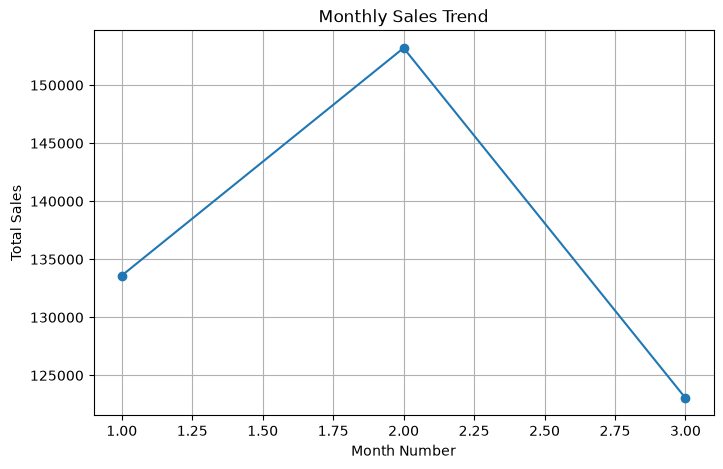

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month Number")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

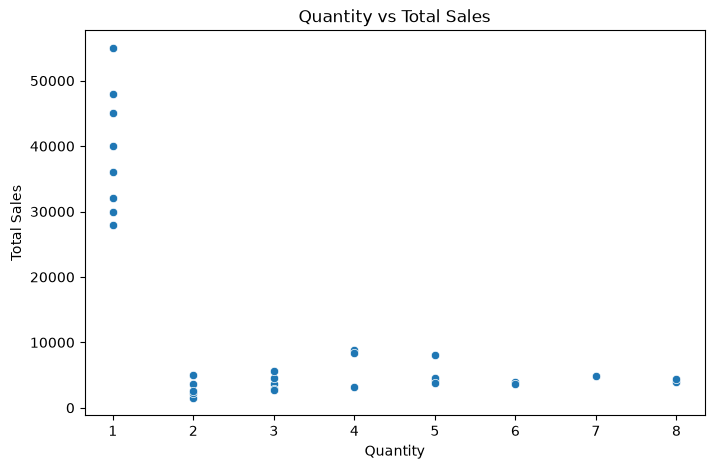

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total_Sales"
)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.show()

In [28]:
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

Rating
3     5
4    15
5    10
Name: count, dtype: int64


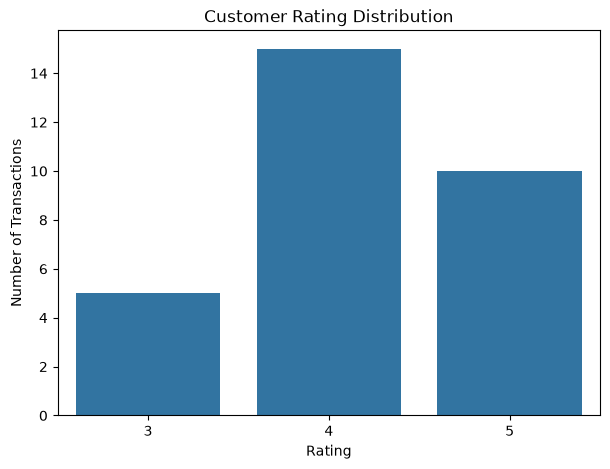

In [29]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Transactions")

plt.show()

In [30]:
numeric_columns = [
    "Unit_Price",
    "Quantity",
    "Total_Sales",
    "Rating"
]

correlation = df[numeric_columns].corr()

correlation

,Unit_Price,Quantity,Total_Sales,Rating
Unit_Price,1.000000,-0.647415,0.996145,0.348388
Quantity,-0.647415,1.000000,-0.611891,-0.287871
Total_Sales,0.996145,-0.611891,1.000000,0.368585
Rating,0.348388,-0.287871,0.368585,1.000000


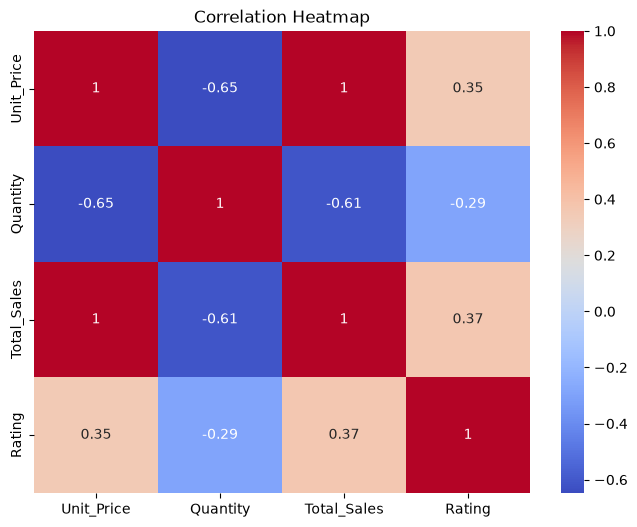

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
top_sales = df.sort_values(
    by="Total_Sales",
    ascending=False
)

top_sales.head(10)

,Invoice_ID,Date,Customer_Type,Gender,Product_Category,Unit_Price,Quantity,Payment_Method,City,Total_Sales,Rating,Month,Month_Number
11,INV012,2026-02-05,Normal,Male,Electronics,55000,1,Card,Vadodara,55000,5,February,2
22,INV023,2026-03-08,Member,Male,Electronics,48000,1,Card,Ahmedabad,48000,5,March,3
0,INV001,2026-01-05,Member,Female,Electronics,45000,1,UPI,Dahod,45000,5,January,1
15,INV016,2026-02-18,Normal,Female,Electronics,40000,1,Card,Dahod,40000,4,February,2
26,INV027,2026-03-18,Member,Female,Electronics,36000,1,Card,Vadodara,36000,4,March,3
4,INV005,2026-01-12,Member,Female,Electronics,32000,1,UPI,Ahmedabad,32000,4,January,1
19,INV020,2026-02-28,Normal,Male,Electronics,30000,1,Card,Ahmedabad,30000,5,February,2
8,INV009,2026-01-22,Member,Female,Electronics,28000,1,Card,Vadodara,28000,4,January,1
9,INV010,2026-01-25,Normal,Male,Clothing,2200,4,UPI,Dahod,8800,4,January,1
24,INV025,2026-03-12,Member,Female,Clothing,2100,4,Cash,Dahod,8400,5,March,3


In [33]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

print("Highest Sales Category:", best_category)
print("Sales:", best_category_sales)

Highest Sales Category: Electronics
Sales: 314000


In [34]:
print("RETAIL SALES ANALYSIS SUMMARY")
print("-" * 40)

print("Total Sales:", round(df["Total_Sales"].sum(), 2))
print("Total Quantity Sold:", df["Quantity"].sum())
print("Average Transaction Value:", round(df["Total_Sales"].mean(), 2))
print("Best Product Category:", category_sales.idxmax())
print("Best City:", city_sales.idxmax())
print("Most Used Payment Method:", df["Payment_Method"].mode()[0])
print("Average Customer Rating:", round(df["Rating"].mean(), 2))

RETAIL SALES ANALYSIS SUMMARY
----------------------------------------
Total Sales: 409850
Total Quantity Sold: 100
Average Transaction Value: 13661.67
Best Product Category: Electronics
Best City: Vadodara
Most Used Payment Method: UPI
Average Customer Rating: 4.17
